In [1]:
# Cell 1
import rasterio
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 10)

# 1. Load the Sentinel-1 VH (Vertical Transmit, Horizontal Receive) band.
# VH polarization is highly sensitive to "volume scattering" (like tree branches),
# making it excellent for finding forests or detecting crop growth.
with rasterio.open("data/s1_vh.tif") as src:
    sar_vh_linear = src.read(1).astype(float)
    
    # Unlike optical data (0.0 to 1.0), raw SAR linear power values are often tiny decimals.
    print(f"Raw SAR values range from {np.nanmin(sar_vh_linear)} to {np.nanmax(sar_vh_linear)}")

# Ignore division by zero warnings
np.seterr(divide='ignore', invalid='ignore')
print("SAR data loaded!")


Raw SAR values range from -32768.0 to 381.7239074707031
SAR data loaded!


Decibel values range from -32.65 dB to 25.82 dB


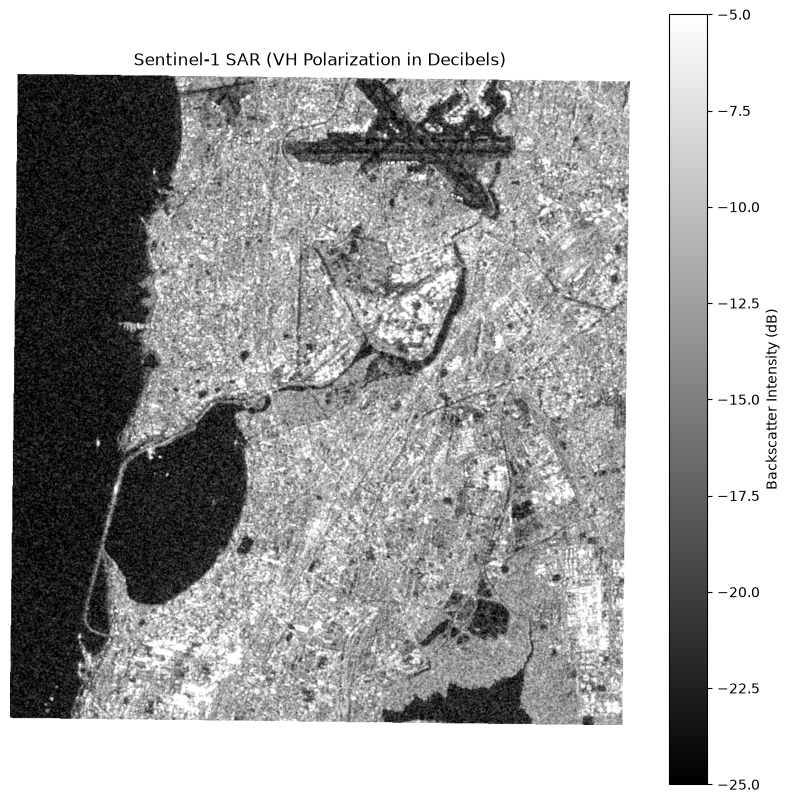

In [2]:
# Cell 2
# The mathematical conversion from Linear Power to Decibels (dB)
# Formula: 10 * log10(linear_value)
# We add a tiny number (1e-10) so we don't accidentally try to calculate log10 of exactly 0
sar_vh_db = 10 * np.log10(sar_vh_linear + 1e-10)

print(f"Decibel values range from {np.nanmin(sar_vh_db):.2f} dB to {np.nanmax(sar_vh_db):.2f} dB")
# Typical VH values range from -30 dB (water/smooth surfaces) to -5 dB (dense cities/forests)

plt.figure()
# We use a grayscale colormap. 
# Bright white = High backscatter (buildings, rough ground)
# Dark black = Low backscatter (calm water, smooth airport runways)
plt.imshow(sar_vh_db, cmap='gray', vmin=-25, vmax=-5)
plt.colorbar(label='Backscatter Intensity (dB)')
plt.title("Sentinel-1 SAR (VH Polarization in Decibels)")
plt.axis("off")
plt.show()


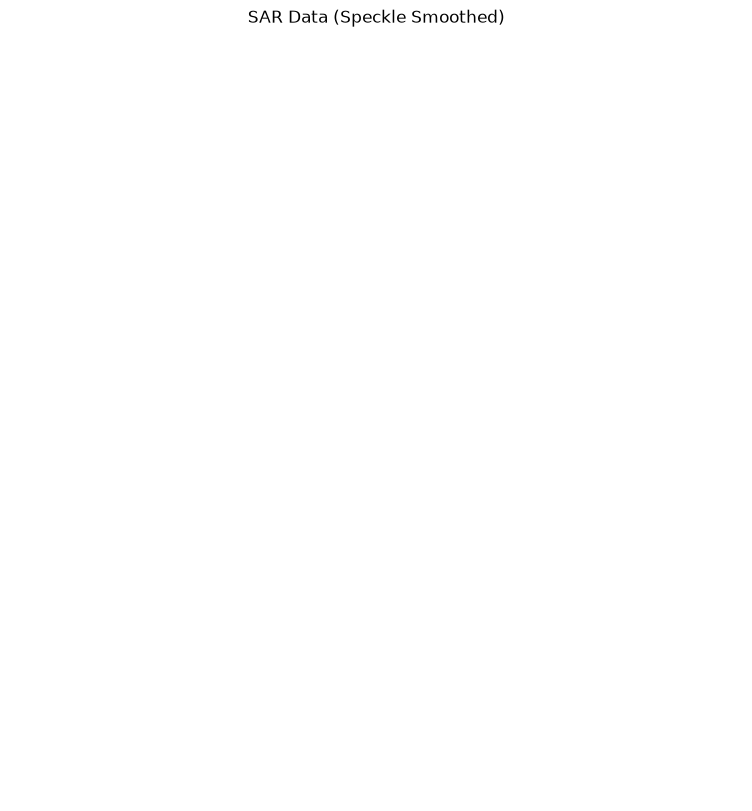

In [3]:
# Cell 3
from scipy.ndimage import uniform_filter

# Apply a simple 5x5 average filter to "blur" out the speckle noise
# Note: In production, you would use a Lee or Frost filter, but a mean filter works for our visual exploration!
sar_vh_smoothed = uniform_filter(sar_vh_db, size=5)

plt.figure()
plt.imshow(sar_vh_smoothed, cmap='gray', vmin=-25, vmax=-5)
plt.title("SAR Data (Speckle Smoothed)")
plt.axis("off")
plt.show()


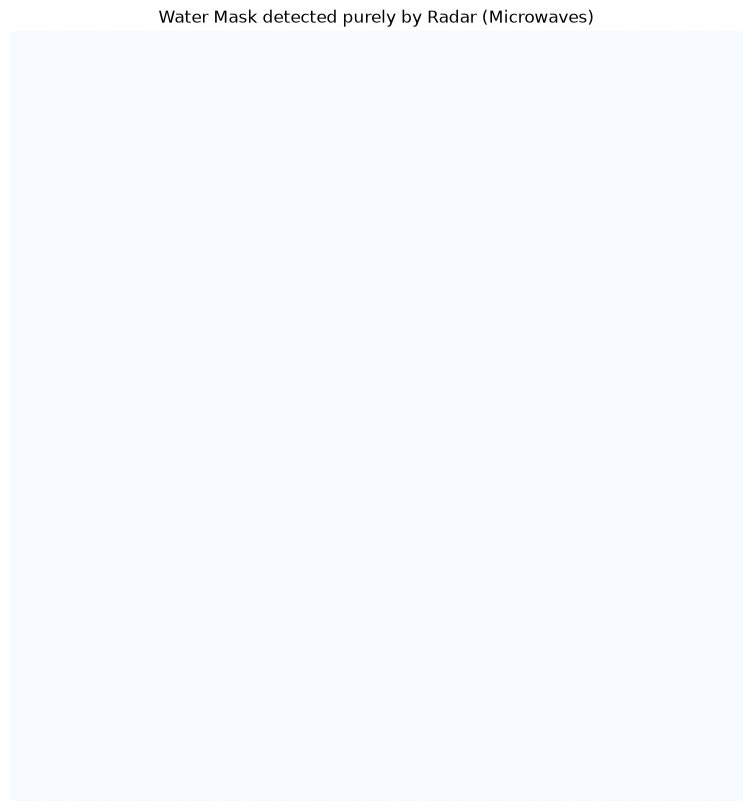

In [4]:
# Cell 4
# Let's create an AI mask for water using just Radar!
# Anything darker than -20 dB in the smoothed VH band is likely flat water.
sar_water_mask = (sar_vh_smoothed < -20.0)

plt.figure()
plt.imshow(sar_water_mask, cmap='Blues')
plt.title("Water Mask detected purely by Radar (Microwaves)")
plt.axis("off")
plt.show()


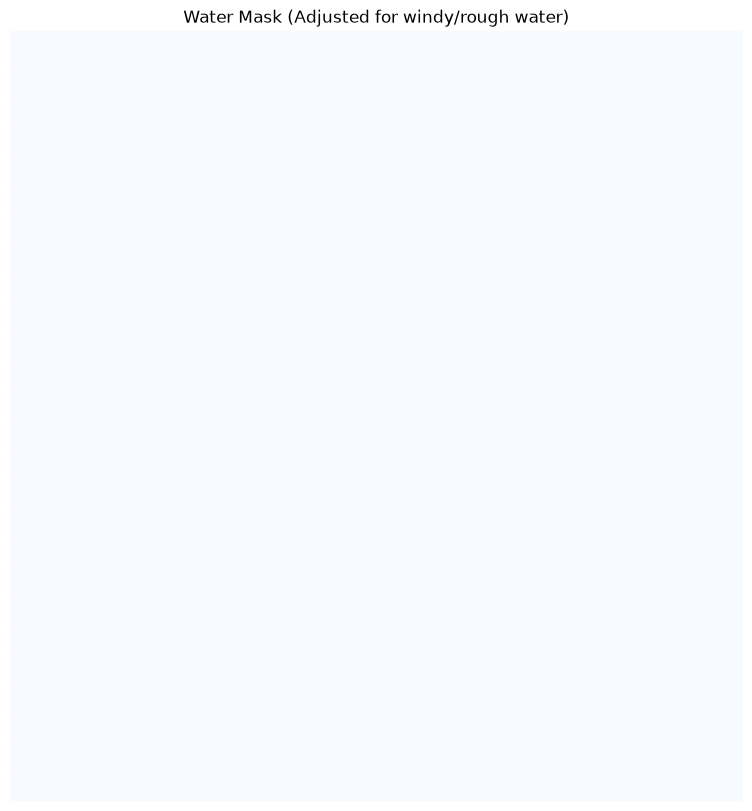

In [5]:
# Change the threshold from -20.0 to -14.0
sar_water_mask = (sar_vh_smoothed < -14.0)

plt.figure()
plt.imshow(sar_water_mask, cmap='Blues')
plt.title("Water Mask (Adjusted for windy/rough water)")
plt.axis("off")
plt.show()


In [6]:
print(f"Darkest pixel (Min dB): {np.nanmin(sar_vh_smoothed):.2f}")
print(f"Brightest pixel (Max dB): {np.nanmax(sar_vh_smoothed):.2f}")
print(f"Number of 'Water' pixels: {np.sum(sar_water_mask)}")


Darkest pixel (Min dB): nan
Brightest pixel (Max dB): nan
Number of 'Water' pixels: 0


C:\Users\Mobil\AppData\Local\Temp\ipykernel_4104\2764584066.py:1: RuntimeWarning: All-NaN slice encountered
  print(f"Darkest pixel (Min dB): {np.nanmin(sar_vh_smoothed):.2f}")
C:\Users\Mobil\AppData\Local\Temp\ipykernel_4104\2764584066.py:2: RuntimeWarning: All-NaN slice encountered
  print(f"Brightest pixel (Max dB): {np.nanmax(sar_vh_smoothed):.2f}")


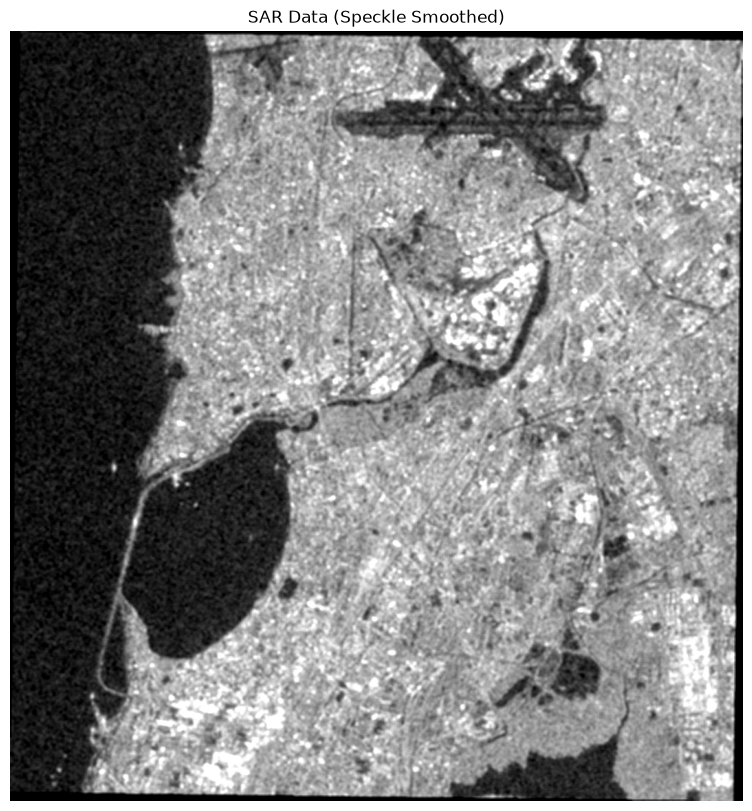

In [7]:
# Cell 3
from scipy.ndimage import uniform_filter

# FIX: Replace all NaNs (empty data) with -30 dB so it doesn't break our math
sar_vh_db_clean = np.nan_to_num(sar_vh_db, nan=-30.0, neginf=-30.0, posinf=-30.0)

# NOW we smooth it safely
sar_vh_smoothed = uniform_filter(sar_vh_db_clean, size=5)

plt.figure()
plt.imshow(sar_vh_smoothed, cmap='gray', vmin=-25, vmax=-5)
plt.title("SAR Data (Speckle Smoothed)")
plt.axis("off")
plt.show()


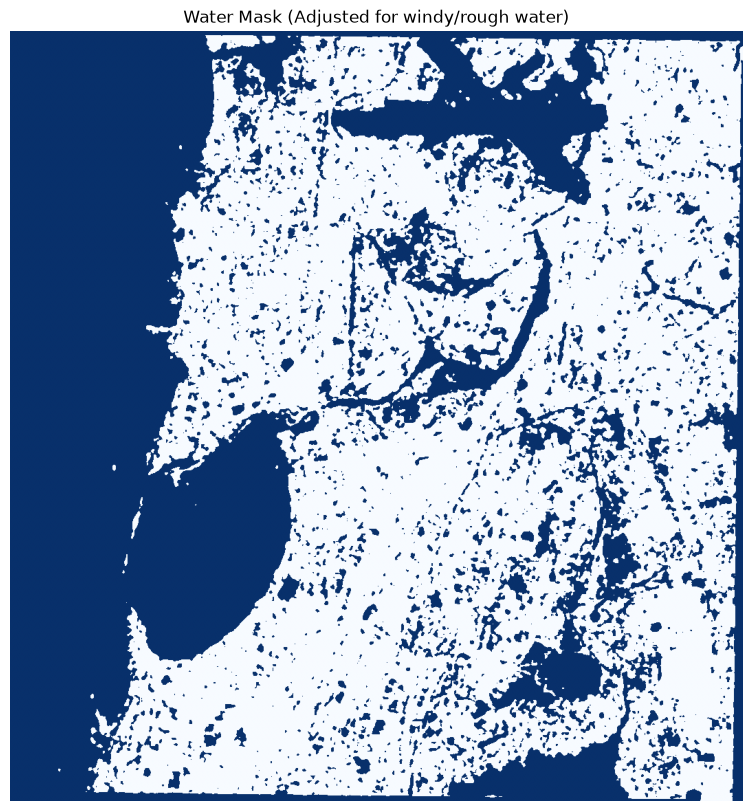

In [8]:
# Change the threshold from -20.0 to -14.0
sar_water_mask = (sar_vh_smoothed < -14.0)

plt.figure()
plt.imshow(sar_water_mask, cmap='Blues')
plt.title("Water Mask (Adjusted for windy/rough water)")
plt.axis("off")
plt.show()
